In [3]:
import tensorflow as tf 
print("tensorflow version se ",tf.__version__)

tensorflow version se  2.21.0


In [4]:
mnist=tf.keras.datasets.mnist

In [5]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [6]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [7]:
x_train[5998]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 105, 253,  65,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 148, 224,  14,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 150, 245, 159,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 211, 253,  63,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [8]:
x_train[0][1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

In [9]:
import sys
print(sys.executable)

c:\Users\Jagdish singh\jupyter311\Scripts\python.exe


In [10]:
import matplotlib.pyplot as plt


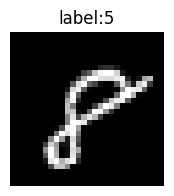

In [11]:
plt.figure(figsize=(2,2))
plt.imshow(x_train[59999], cmap='gray')   # gray is standard spelling
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

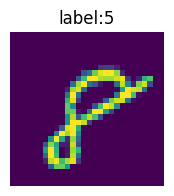

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[59999])   # gray without it  heatmap
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

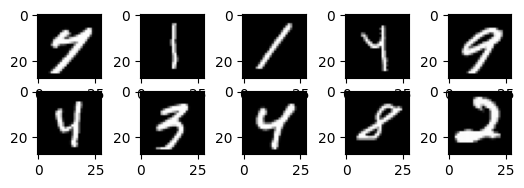

In [13]:
for i in range(1,11):
    plt.subplot(5,5,i)
    plt.imshow(x_train[i+1000],cmap='grey')
    
plt.show()

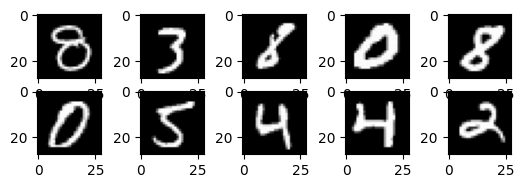

In [14]:
import random
import numpy as np

for i in range(1,11):
    plt.subplot(5,5,i)
    index=np.random.randint(0,59999)
    plt.imshow(x_train[index],cmap='grey')
    
plt.show()
# using np.random.randit to genrte random numbers for visualization


In [15]:
x_train=x_train/255.0
x_test=x_test/255.0

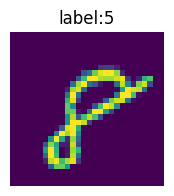

In [16]:
plt.figure(figsize=(2,2))
plt.imshow(x_train[59999])   # after scaling/normlizing data the image quality effects
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras import Input

In [18]:
# Sequential: Container to build neural network layer-by-layer in a linear stack.
# Input: Defines the shape/size of data entering the model.
# Flatten: Converts multi-dimensional input (e.g., 28x28 image) into a 1D vector.
# Dense: Fully connected layer where neurons learn patterns using weights and activation functions.

In [19]:
model=Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [20]:
'''A Dense layer is a type of layer where:
every neuron connects to all neurons in the previous layer
(fully connected layer).

#  hidden layer is any layer between input and output of a neural network.'''

'A Dense layer is a type of layer where:\nevery neuron connects to all neurons in the previous layer\n(fully connected layer).\n\n#  hidden layer is any layer between input and output of a neural network.'

In [21]:
# Binary Classification: sigmoid  //same like log regression
# Multi-class Classification: softmax  //same like mutlinomail log regresion
# Regression: linear

##  Each layer has a different job, so it needs a different activation behavior.

In [22]:
#  compiling fit the engine optimize it and reduce fuel loss
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])


In [23]:
# Model is tested on validation after each epochs 
# validation_data is used to evaluate model performance on unseen data after each epoch without updating weights, helping detect overfitting and monitor generalization ability.

In [24]:
# batch size =32/ number of training samples processed before updating model weights once.

In [25]:
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9338 - loss: 0.2197 - val_accuracy: 0.9693 - val_loss: 0.1019
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9703 - loss: 0.0946 - val_accuracy: 0.9717 - val_loss: 0.0909
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9789 - loss: 0.0648 - val_accuracy: 0.9735 - val_loss: 0.0864
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9840 - loss: 0.0497 - val_accuracy: 0.9719 - val_loss: 0.1025
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9869 - loss: 0.0396 - val_accuracy: 0.9772 - val_loss: 0.0792
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9894 - loss: 0.0328 - val_accuracy: 0.9779 - val_loss: 0.0826
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9911 - loss: 0.0264 - val_accuracy: 0.9778 - val_loss: 0.0888
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9917 - loss: 0.0248 -

In [26]:
# r is object returned by model ..it is called as history object 
# r stores all training results during training..

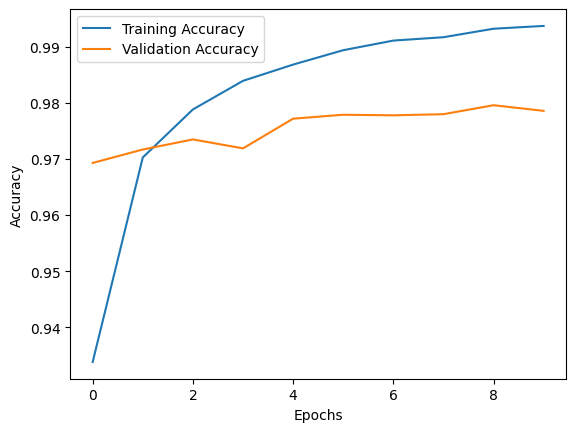

In [27]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
# Both training and validation accuracy increase together and remain close, indicating good learning and proper generalization.”

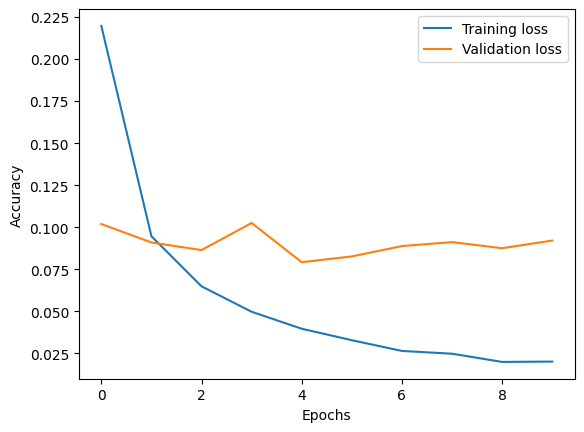

In [29]:
plt.plot(r.history['loss'], label='Training loss ')
plt.plot(r.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [30]:
x_test.shape   # for test You have 10,000 grayscale images, each of size 28×28 pixels.

(10000, 28, 28)

In [31]:
model.predict(x_test).shape # 10 is no. of output neurons and is equal to number of classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [32]:
model.predict(x_test)[0] # model predict 10 classes for each image btw 0-9

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([2.2718920e-09, 1.8419050e-10, 1.6083419e-07, 2.8501960e-08,
       5.9038538e-13, 1.2740513e-13, 3.1585588e-15, 9.9999988e-01,
       9.6007639e-11, 5.8179905e-09], dtype=float32)

In [33]:
import numpy as np
y_pred = model.predict(x_test).argmax(axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [34]:
!py -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 971,    0,    2,    0,    2,    0,    2,    0,    1,    2],
       [   0, 1128,    4,    0,    0,    0,    1,    1,    1,    0],
       [   2,    2, 1007,    2,    4,    0,    1,    6,    7,    1],
       [   1,    0,    3,  983,    0,    1,    0,    8,    4,   10],
       [   2,    1,    2,    0,  966,    0,    5,    1,    0,    5],
       [   2,    1,    0,    8,    3,  864,    3,    1,    3,    7],
       [   5,    2,    2,    0,    4,    9,  935,    0,    1,    0],
       [   2,    7,    5,    2,    3,    0,    0,  995,    4,   10],
       [   5,    2,    3,    2,    3,    3,    1,    2,  947,    6],
       [   2,    2,    0,    0,   11,    2,    0,    1,    1,  990]])

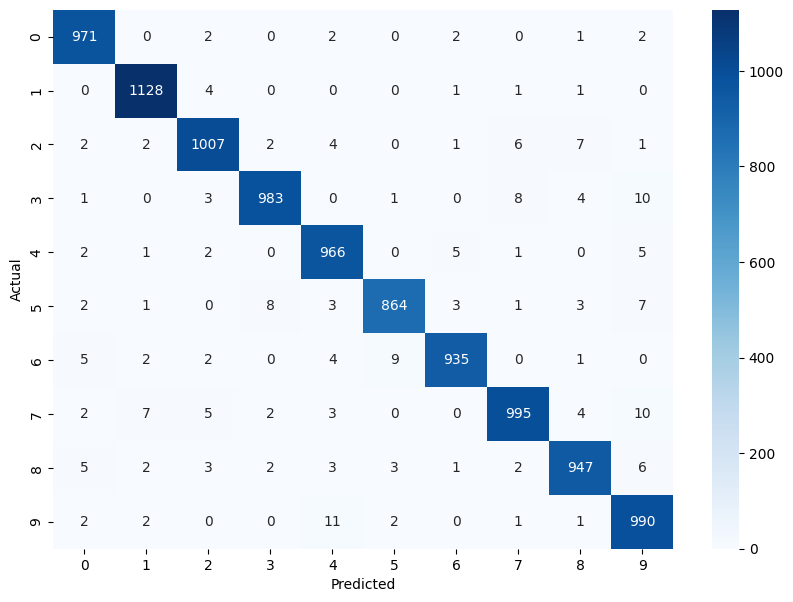

In [36]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [37]:
np.where(y_test != y_pred)  # provide the indexes np.where

(array([ 115,  149,  217,  247,  259,  340,  358,  381,  445,  495,  582,
         659,  684,  691,  720,  844,  846,  877,  947,  951,  956, 1014,
        1039, 1112, 1128, 1156, 1194, 1226, 1232, 1242, 1247, 1299, 1319,
        1328, 1393, 1395, 1494, 1500, 1522, 1530, 1549, 1601, 1609, 1626,
        1681, 1717, 1722, 1730, 1737, 1754, 1790, 1878, 1901, 1982, 1987,
        2004, 2033, 2035, 2040, 2073, 2093, 2109, 2118, 2125, 2130, 2135,
        2291, 2293, 2369, 2387, 2408, 2414, 2422, 2426, 2433, 2462, 2488,
        2597, 2607, 2654, 2730, 2742, 2877, 2919, 2921, 2939, 2953, 3012,
        3030, 3073, 3115, 3117, 3225, 3422, 3441, 3451, 3475, 3503, 3520,
        3558, 3776, 3780, 3796, 3818, 3853, 3893, 3906, 3941, 3976, 3985,
        4000, 4007, 4027, 4063, 4065, 4140, 4154, 4176, 4199, 4201, 4211,
        4289, 4317, 4355, 4425, 4487, 4497, 4504, 4551, 4571, 4615, 4639,
        4671, 4807, 4814, 4823, 4860, 4876, 4879, 4880, 4943, 4956, 5586,
        5600, 5634, 5642, 5654, 5676, 

In [38]:
len(np.where(y_test != y_pred)[0]) # no of wrong predictions

214

In [39]:
(270/10000) * 100 
100 - 2.7

97.3

In [40]:
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_indices

array([ 115,  149,  217,  247,  259,  340,  358,  381,  445,  495,  582,
        659,  684,  691,  720,  844,  846,  877,  947,  951,  956, 1014,
       1039, 1112, 1128, 1156, 1194, 1226, 1232, 1242, 1247, 1299, 1319,
       1328, 1393, 1395, 1494, 1500, 1522, 1530, 1549, 1601, 1609, 1626,
       1681, 1717, 1722, 1730, 1737, 1754, 1790, 1878, 1901, 1982, 1987,
       2004, 2033, 2035, 2040, 2073, 2093, 2109, 2118, 2125, 2130, 2135,
       2291, 2293, 2369, 2387, 2408, 2414, 2422, 2426, 2433, 2462, 2488,
       2597, 2607, 2654, 2730, 2742, 2877, 2919, 2921, 2939, 2953, 3012,
       3030, 3073, 3115, 3117, 3225, 3422, 3441, 3451, 3475, 3503, 3520,
       3558, 3776, 3780, 3796, 3818, 3853, 3893, 3906, 3941, 3976, 3985,
       4000, 4007, 4027, 4063, 4065, 4140, 4154, 4176, 4199, 4201, 4211,
       4289, 4317, 4355, 4425, 4487, 4497, 4504, 4551, 4571, 4615, 4639,
       4671, 4807, 4814, 4823, 4860, 4876, 4879, 4880, 4943, 4956, 5586,
       5600, 5634, 5642, 5654, 5676, 5734, 5745, 58

In [41]:
print(f'Total misclassified images: {len(misclassified_indices)}')


Total misclassified images: 214


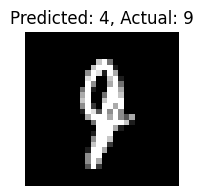

In [42]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')  #inshow for image plotiing
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

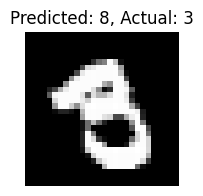

In [43]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

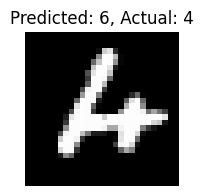

In [44]:

i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

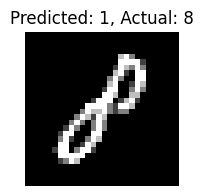

In [45]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

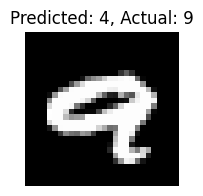

In [46]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9978 - loss: 0.0071 - val_accuracy: 0.9829 - val_loss: 0.0784
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9990 - loss: 0.0042 - val_accuracy: 0.9831 - val_loss: 0.0767
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9993 - loss: 0.0033 - val_accuracy: 0.9837 - val_loss: 0.0763
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9995 - loss: 0.0027 - val_accuracy: 0.9838 - val_loss: 0.0762
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9997 - loss: 0.0023 - val_accuracy: 0.9838 - val_loss: 0.0765
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 0.9840 - val_loss: 0.0765
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9998 - loss: 0.0019 - val_accuracy: 0.9841 - val_loss: 0.0769
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9998 - loss: 0.0017 - val_

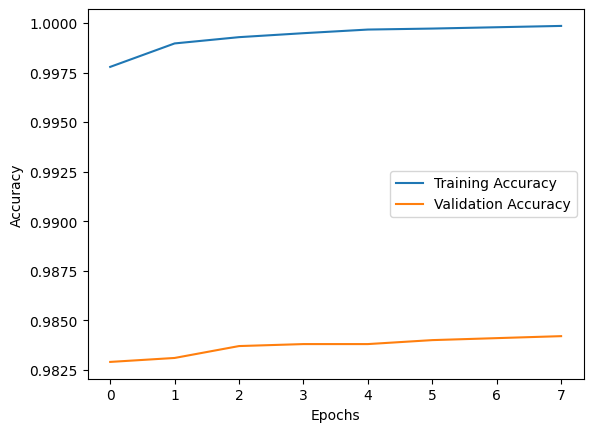

In [47]:
model.compile(optimizer='sgd',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=8)
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

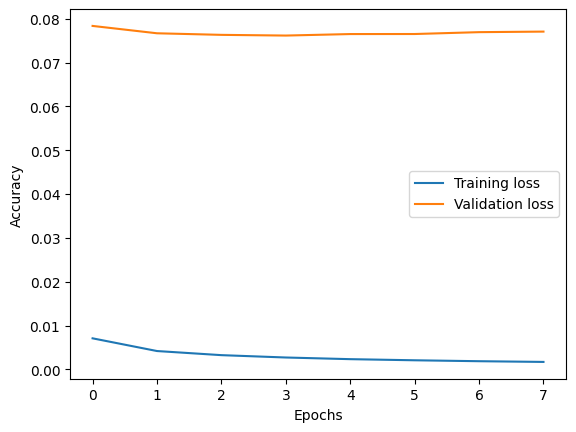

In [48]:
plt.plot(r.history['loss'], label='Training loss ')
plt.plot(r.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Epoch 1/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9999 - loss: 0.0016 - val_accuracy: 0.9841 - val_loss: 0.0772
Epoch 2/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9841 - val_loss: 0.0773
Epoch 3/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9840 - val_loss: 0.0774
Epoch 4/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9839 - val_loss: 0.0775
Epoch 5/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9838 - val_loss: 0.0776
Epoch 6/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9838 - val_loss: 0.0776
Epoch 7/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.9838 - val_loss: 0.0777
Epoch 8/9
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9999 - loss: 0.0014 - val_ac

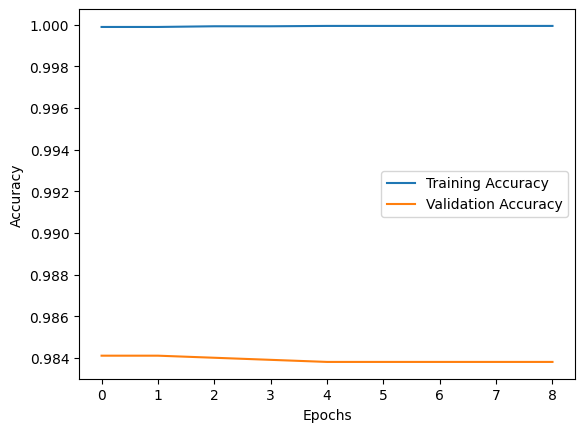

In [49]:
model.compile(optimizer='adagrad',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=9)
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [50]:
model=Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

In [51]:
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10)



Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9155 - loss: 0.2792 - val_accuracy: 0.9625 - val_loss: 0.1210
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9584 - loss: 0.1380 - val_accuracy: 0.9683 - val_loss: 0.0984
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9670 - loss: 0.1075 - val_accuracy: 0.9737 - val_loss: 0.0854
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9713 - loss: 0.0908 - val_accuracy: 0.9767 - val_loss: 0.0817
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9738 - loss: 0.0814 - val_accuracy: 0.9769 - val_loss: 0.0753
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9767 - loss: 0.0717 - val_accuracy: 0.9783 - val_loss: 0.0715
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9795 - loss: 0.0651 - val_accuracy: 0.9798 - val_loss: 0.0668
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9795 - loss: 0.0633 

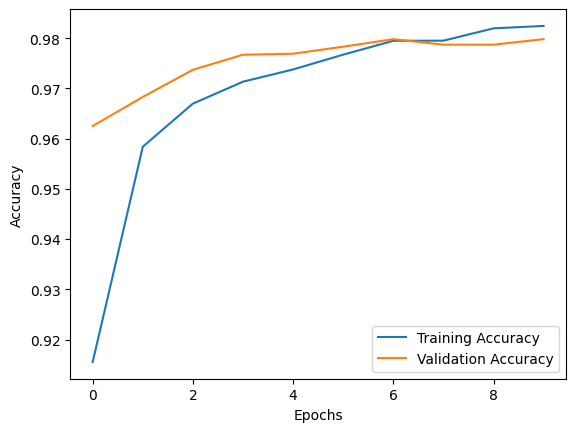

In [52]:
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [53]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,min_delta=.001
)
model=Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=20,callbacks=early_stop)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - accuracy: 0.9144 - loss: 0.2800 - val_accuracy: 0.9609 - val_loss: 0.1246
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9571 - loss: 0.1399 - val_accuracy: 0.9700 - val_loss: 0.0974
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9660 - loss: 0.1089 - val_accuracy: 0.9719 - val_loss: 0.0994
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9708 - loss: 0.0931 - val_accuracy: 0.9737 - val_loss: 0.0841
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9736 - loss: 0.0824 - val_accuracy: 0.9781 - val_loss: 0.0724
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9765 - loss: 0.0731 - val_accuracy: 0.9784 - val_loss: 0.0751
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9786 - loss: 0.0664 - val_accuracy: 0.9775 - val_loss: 0.0802
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9801 - loss: 0.061

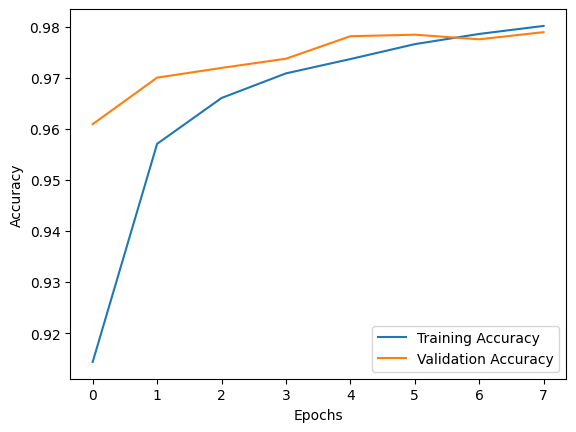

In [54]:
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show() 